## Application of Transpose Convolution  



#### Steps: 
**Step 1: Import Necessary Libraries**



In [4]:
import warnings
warnings.simplefilter('ignore')
import tensorflow as tf 

from tensorflow.keras.models import Model 

from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, UpSampling2D 

import numpy as np 

import matplotlib.pyplot as plt 



 
**Step 2: Define the Input Layer**
 

 


In [ ]:
input_layer = Input(shape=(28, 28, 1))

**Step 3: Add convolutional and transpose convolutional layers**



In [6]:
conv_layer = Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same')(input_layer) 

transpose_conv_layer = Conv2DTranspose(filters=1, kernel_size=(3, 3), activation='sigmoid', padding='same')(conv_layer) 



**Step 4: Create the Model**




In [7]:
model = Model(inputs=input_layer, outputs=transpose_conv_layer)



**Step 5: Compile the Model**




In [8]:
model.compile(optimizer='adam', loss='mean_squared_error')

**Step 6: Train the Model**



In [9]:


X_train = np.random.rand(1000, 28, 28, 1) 

y_train = X_train  

history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2) 

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0725 - val_loss: 0.0583
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0448 - val_loss: 0.0313
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0223 - val_loss: 0.0146
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0105 - val_loss: 0.0073
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0057 - val_loss: 0.0045
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0039 - val_loss: 0.0034
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0031 - val_loss: 0.0028
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0026 - val_loss: 0.0024
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0023 - val_loss: 0.0021
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0020 - val_loss: 0.0019




  
**Step 7: Evaluate the Model**



In [10]:


X_test = np.random.rand(200, 28, 28, 1) 

y_test = X_test 

loss = model.evaluate(X_test, y_test) 

print(f'Test loss: {loss}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0019 
Test loss: 0.0019172796746715903



**Step 8: Visualize the Results**



7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


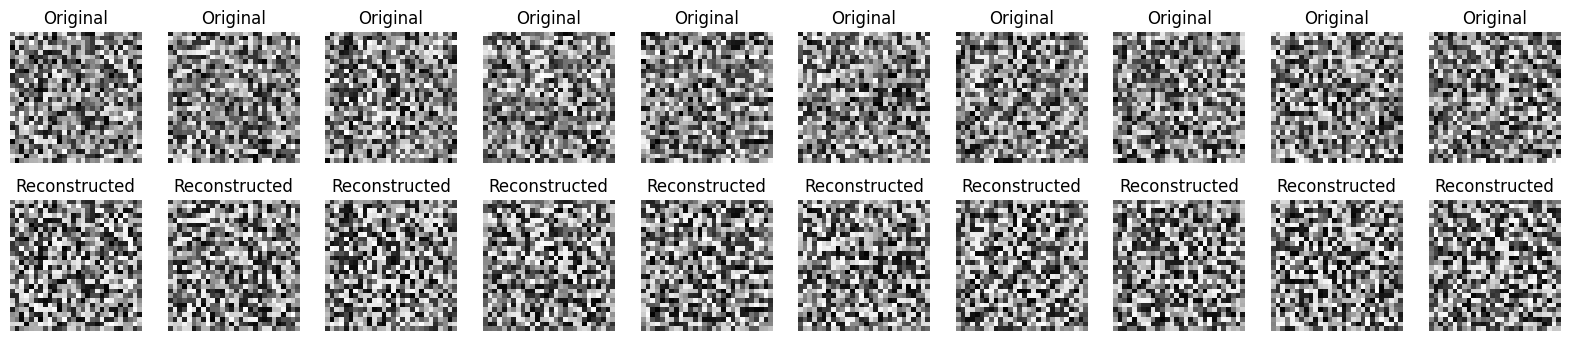

In [11]:

y_pred = model.predict(X_test) 

n = 10 

plt.figure(figsize=(20, 4))

for i in range(n): 
 
    ax = plt.subplot(2, n, i + 1) 
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original") 
    plt.axis('off') 
    ax = plt.subplot(2, n, i + 1 + n) 
    plt.imshow(y_pred[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show() 